# 08 — Dynamic GCOV Visualization and RGB Composite

This module plots whichever real-valued GCOV terms are available, and where possible builds a co-pol/cross-pol ratio plus an RGB composite from them.

The RGB channels are R = co-pol (dB), G = cross-pol (dB), B = the co-pol/cross-pol ratio (dB). Three pairs are tried in order: HHHH/HVHV, then VVVV/VHVH, then RHRH/RVRV (SSAR compact-pol, which never carries H/V terms at all).

**Mask handling:** the GCOV `mask` dataset is read on the same native subset used for everything else. Wherever `MASK == 0`, the corresponding pixel in HHHH/HVHV/RHRH/RVRV is set to NaN before it's plotted individually, before the ratio is computed, and before it goes into the RGB composite — so invalid pixels never contribute to any of the three. The source HDF5 file is read-only throughout; nothing is modified.

Complex terms never get plotted here — only real, diagonal terms make it into these images.

Plots are in longitude/latitude (WGS84 / EPSG:4326), reprojected from whatever native CRS the product actually uses.

## Map-aware visualization

Before the detailed GCOV plots, you'll see the scene/AOI in geographic context — the underlying visualization logic itself hasn't changed.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from nisar_utils.bootstrap import setup_workshop
WORKSHOP_ROOT = setup_workshop()

from nisar_utils.config import load_config
from nisar_utils.workflow import (
    build_profile, resolve_frequency, resolve_terms, resolve_window
)
from nisar_utils.gcov import open_gcov, read_window
from nisar_utils.spatial import coordinate_to_index
from nisar_utils.visualization import plot_gcov
from pyproj import Transformer

cfg = load_config()
NISAR_FILE = Path(cfg["nisar_file"])

# ------------------------------------------------------------------
# Unique pass identification for time-series analysis.
# Extract the mission track/frame/pass/date from the NISAR filename
# without changing any existing processing logic.
# ------------------------------------------------------------------
import re
from datetime import datetime

_PRODUCT_NAME = NISAR_FILE.stem

def _extract_pass_metadata(name):
    # Official NISAR GCOV naming:
    # NISAR_IL_PT_PROD_CYL_REL_P_FRM_MODE_POLE_S_StartDateTime_EndDateTime_...
    #
    # Example:
    # NISAR_L2_UR_GCOV_029_048_D_074_2005_QPDH_A_20260828T125812_...
    #
    # 029 = cycle number
    # 048 = relative orbit track number
    # D   = orbit direction / pass
    # 074 = frame number
    m = re.search(
        r"(?P<cycle>\d{3})_(?P<track>\d{3})_(?P<pass>[AD])_"
        r"(?P<frame>\d{3})_(?P<mode>[^_]+)_(?P<pole>[^_]+)_"
        r"(?P<source>[AM])_"
        r"(?P<start>\d{8}T\d{6})_(?P<stop>\d{8}T\d{6})",
        name,
        flags=re.IGNORECASE,
    )

    if m:
        return {
            "cycle": m.group("cycle"),
            "track": m.group("track"),
            "frame": m.group("frame"),
            "pass": m.group("pass").upper(),
            "start": m.group("start"),
            "stop": m.group("stop"),
        }

    raise RuntimeError(
        "Could not parse the official NISAR GCOV filename convention. "
        "Expected ..._<CYCLE>_<TRACK>_<A/D>_<FRAME>_<MODE>_<POLE>_"
        "<SOURCE>_<START>_<STOP>..."
    )

PASS_META = _extract_pass_metadata(_PRODUCT_NAME)

def _format_pass_date(timestamp):
    if timestamp == "N/A":
        return "N/A"
    try:
        return datetime.strptime(timestamp, "%Y%m%dT%H%M%S").strftime("%Y-%m-%d")
    except ValueError:
        return timestamp[:8] if len(timestamp) >= 8 else timestamp

PASS_DATE = _format_pass_date(PASS_META["start"])

PASS_DIRECTION = {
    "A": "Ascending",
    "D": "Descending",
}.get(PASS_META["pass"], PASS_META["pass"])

PASS_ID = (
    f"Track {PASS_META['track']} | "
    f"Frame {PASS_META['frame']} | "
    f"{PASS_DIRECTION} | "
    f"{PASS_DATE}"
)

print("Pass identification:", PASS_ID)

# Filesystem-safe unique identifier for this NISAR acquisition.
def _safe_token(value):
    return re.sub(r"[^A-Za-z0-9.-]+", "_", str(value)).strip("_")

# Compact acquisition identifier uses Track + Frame + Pass + Date.
# Cycle is parsed separately and is not substituted for Track.
# Example: NISAR_SSAR_010_113_A_20260117
profile = build_profile(cfg)
freq = resolve_frequency(cfg, profile)
terms, diagonal_terms, off_diagonal_terms = resolve_terms(profile, freq)

SAR_TOKEN = _safe_token(getattr(profile, "sar_family", "SAR"))
# Resolve ascending/descending pass. Filename parsing is the first source;
# when it is not decisive, inspect the product metadata exposed by h5py.
def _resolve_pass_code(h5_path, filename_meta):
    if filename_meta.get("pass") in {"A", "D"}:
        return filename_meta["pass"]

    import h5py

    def _norm(v):
        if isinstance(v, bytes):
            v = v.decode("utf-8", errors="ignore")
        v = str(v).strip().upper()
        if v.startswith("ASC"):
            return "A"
        if v.startswith("DES"):
            return "D"
        if v in {"A", "D"}:
            return v
        return None

    candidates = (
        "orbitDirection", "passDirection", "orbit_direction",
        "pass_direction", "acquisitionDirection", "orbitPassDirection",
    )

    with h5py.File(h5_path, "r") as h5:
        for key in candidates:
            if key in h5.attrs:
                code = _norm(h5.attrs[key])
                if code:
                    return code

        found = []
        def visitor(name, obj):
            if found or not hasattr(obj, "attrs"):
                return
            for key in candidates:
                if key in obj.attrs:
                    code = _norm(obj.attrs[key])
                    if code:
                        found.append(code)
                        return

        h5.visititems(visitor)
        if found:
            return found[0]

    raise RuntimeError(
        "Ascending/Descending pass could not be resolved from the NISAR "
        "filename or product metadata. Expected A or D; refusing to use U."
    )

PASS_CODE = _resolve_pass_code(NISAR_FILE, PASS_META)
PASS_DATE_COMPACT = (
    PASS_META["start"][:8]
    if PASS_META["start"] != "N/A"
    else "UNKNOWN"
)

UNIQUE_OUTPUT_NAME = (
    f"NISAR_{SAR_TOKEN}_{PASS_META['track']}_{PASS_META['frame']}_"
    f"{PASS_CODE}_{PASS_DATE_COMPACT}"
)
UNIQUE_OUTPUT_DIR = (
    WORKSHOP_ROOT / "outputs" / "module_08_visualization" / UNIQUE_OUTPUT_NAME
)
UNIQUE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Cycle:", PASS_META["cycle"])
print("Track:", PASS_META["track"])
print("Frame:", PASS_META["frame"])
print("Pass:", PASS_CODE)
print("Unique output folder:", UNIQUE_OUTPUT_DIR)
print("=" * 70)
print("NISAR GCOV VISUALIZATION")
print("=" * 70)
print("File:", NISAR_FILE)
print("SAR family:", profile.sar_family)
print("Band:", profile.band)
print("Level:", profile.product_level)
print("Product:", profile.product_type)
print("GCOV root:", profile.gcov_root)
print("Frequency:", freq)
print("Available terms:", terms)


Pass identification: Track 005 | Frame 075 | Descending | 2026-09-06
Cycle: 030
Track: 005
Frame: 075
Pass: D
Unique output folder: F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906
NISAR GCOV VISUALIZATION
File: E:\NISAR_L2_PR_GCOV_030_005_D_075_2005_QPDH_A_20260906T132343_20260906T132418_P05023_N_F_J_001.h5
SAR family: LSAR
Band: L
Level: L2
Product: GCOV
GCOV root: /science/LSAR/GCOV
Frequency: frequencyA
Available terms: ['HHHH', 'HHHV', 'HHVH', 'HHVV', 'HVHV', 'HVVH', 'HVVV', 'VHVH', 'VHVV', 'VVVV']


In [2]:
# Create a dedicated output directory for Module 08 products.
OUTPUT_DIR = UNIQUE_OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906


Full AOI window: (7056, 12653, 6459, 11507)
Full AOI shape  : (5597, 5048)
Full AOI pixels : 28,253,656
Plot shape      : (2106, 1899)
Plot pixels     : 3,999,294
Plot mode       : AOI-wide resampled for visualization
Plot CRS: WGS84 / EPSG:4326
Selected-pixel longitude: 78.98272023° to 80.00850004°
Selected-pixel latitude : 25.98966104° to 27.01048559°
Requested AOI (WGS84): Lon 79.00000000° to 80.00000000°, Lat 26.00000000° to 27.00000000°

GCOV MASK:
  Dataset: /science/LSAR/GCOV/grids/frequencyA/mask
  Native AOI shape: (5597, 5048)
  MASK == 0 (invalid): 3,043,761
  MASK != 0 (valid): 25,209,895
  Invalid fraction: 10.77%

Term: HHHH
Original AOI shape: (5597, 5048)
Plot shape: (2106, 1899)
Original dtype: float64
Finite pixels after MASK: 28,253,656/28,253,656 (100.00%)
MASK=0 pixels set to NaN: 3,043,761
Display dtype: float64
Display mode: native real


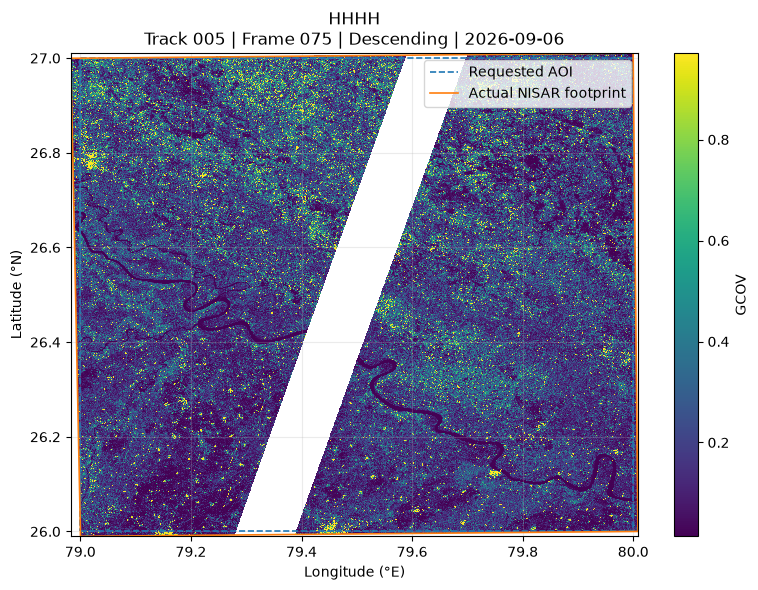


Skipping complex channel: HHHV — complex-valued

Skipping complex channel: HHVH — complex-valued

Skipping complex channel: HHVV — complex-valued

Term: HVHV
Original AOI shape: (5597, 5048)
Plot shape: (2106, 1899)
Original dtype: float64
Finite pixels after MASK: 28,253,656/28,253,656 (100.00%)
MASK=0 pixels set to NaN: 3,043,761
Display dtype: float64
Display mode: native real


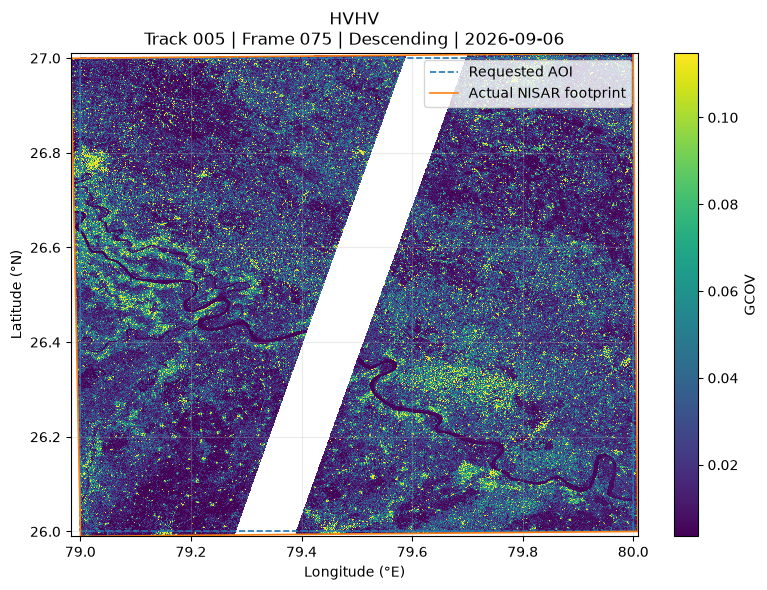


Skipping complex channel: HVVH — complex-valued

Skipping complex channel: HVVV — complex-valued

Term: VHVH
Original AOI shape: (5597, 5048)
Plot shape: (2106, 1899)
Original dtype: float64
Finite pixels after MASK: 28,253,656/28,253,656 (100.00%)
Display dtype: float64
Display mode: native real


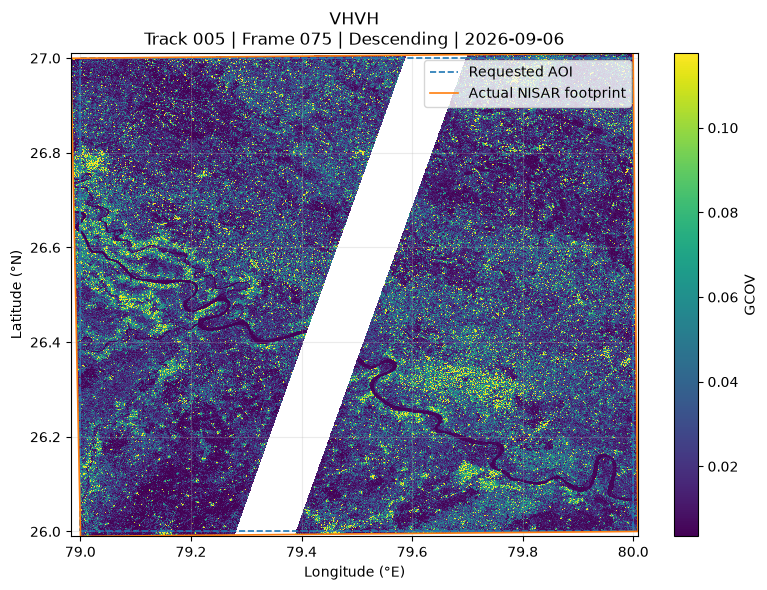


Skipping complex channel: VHVV — complex-valued

Term: VVVV
Original AOI shape: (5597, 5048)
Plot shape: (2106, 1899)
Original dtype: float64
Finite pixels after MASK: 28,253,656/28,253,656 (100.00%)
Display dtype: float64
Display mode: native real


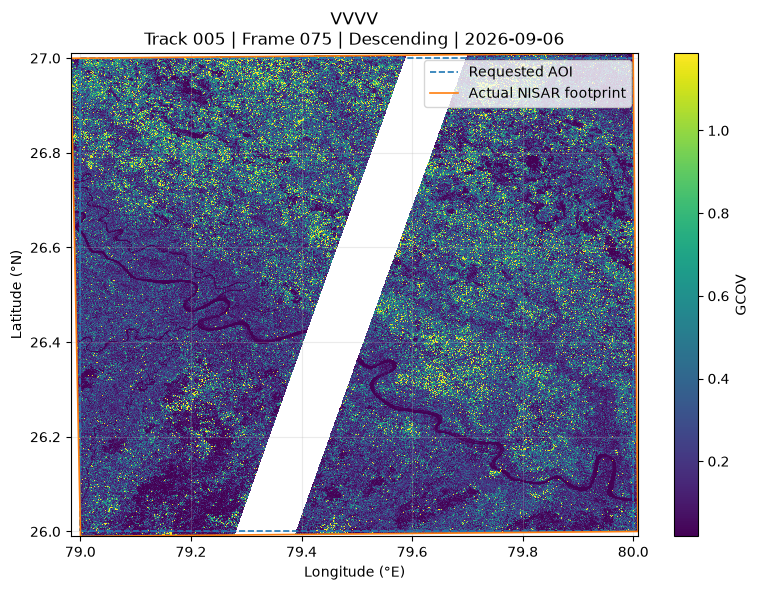


Universal visualization rule:
Real-valued GCOV channels: plotted
Complex-valued channels: skipped for ALL product/polarization modes
Skipped complex channels: HHHV, HHVH, HHVV, HVVH, HVVV, VHVV

GCOV MASK rule:
MASK == 0 -> invalid -> NaN for HHHH/HVHV/RHRH/RVRV
MASK != 0 -> retained
Masking is applied before ratio and RGB generation.

Individual GCOV plots saved.


In [3]:
grid = f"{profile.gcov_root}/grids/{freq}"

with open_gcov(NISAR_FILE) as f:
    x, y = f[f"{grid}/xCoordinates"][:], f[f"{grid}/yCoordinates"][:]

    # Resolve the complete user AOI from persisted configuration.
    # Module 08 must work correctly after a fresh kernel, so it does not
    # depend on live r0/r1/c0/c1 variables from Module 06.
    user_aoi = cfg.get("default_aoi")
    if not isinstance(user_aoi, dict):
        user_aoi = cfg.get("aoi")
    if not isinstance(user_aoi, dict):
        raise RuntimeError(
            "No persisted AOI was found in the configuration. "
            "Run Module 06 once to save the selected AOI."
        )

    def _aoi_value(aoi, names, label):
        for name in names:
            if name in aoi:
                return float(aoi[name])
        raise RuntimeError(
            f"Persisted AOI is missing {label}. Run Module 06 again "
            "to save a complete AOI."
        )

    user_aoi = {
        "xmin": _aoi_value(user_aoi, ("xmin", "lon_min", "longitude_min", "min_lon"), "longitude minimum"),
        "xmax": _aoi_value(user_aoi, ("xmax", "lon_max", "longitude_max", "max_lon"), "longitude maximum"),
        "ymin": _aoi_value(user_aoi, ("ymin", "lat_min", "latitude_min", "min_lat"), "latitude minimum"),
        "ymax": _aoi_value(user_aoi, ("ymax", "lat_max", "latitude_max", "max_lat"), "latitude maximum"),
    }

    if not (user_aoi["xmin"] < user_aoi["xmax"] and user_aoi["ymin"] < user_aoi["ymax"]):
        raise ValueError(f"Invalid persisted AOI: {user_aoi}")

    # Module 06 is authoritative for the native NISAR subset.
    # Use its persisted r0/r1/c0/c1 directly. Do NOT pass the WGS84 AOI
    # back through resolve_window(), because that resolver expects the
    # framework's native/projected AOI representation.
    spatial_cfg = cfg.get("spatial_subset")
    if not isinstance(spatial_cfg, dict) or not all(
        k in spatial_cfg for k in ("r0", "r1", "c0", "c1")
    ):
        raise RuntimeError(
            "No complete persisted native AOI subset was found. "
            "Run Module 06 successfully before Module 08."
        )

    r0 = int(spatial_cfg["r0"])
    r1 = int(spatial_cfg["r1"])
    c0 = int(spatial_cfg["c0"])
    c1 = int(spatial_cfg["c1"])

    full_rows = r1 - r0
    full_cols = c1 - c0
    full_pixels = full_rows * full_cols

    # Default for a 16 GB RAM training workstation.
    # This limits the plotting representation, NOT the scientific subset.
    MAX_PLOT_PIXELS = int(cfg.get("max_plot_pixels", 4_000_000))
    if MAX_PLOT_PIXELS < 1:
        raise ValueError("max_plot_pixels must be a positive integer.")

    if full_pixels > MAX_PLOT_PIXELS:
        scale = (MAX_PLOT_PIXELS / full_pixels) ** 0.5
        plot_rows = max(1, int(round(full_rows * scale)))
        plot_cols = max(1, int(round(full_cols * scale)))
        plot_mode = "AOI-wide resampled for visualization"
    else:
        plot_rows, plot_cols = full_rows, full_cols
        plot_mode = "Full AOI at native resolution"

    print("Full AOI window:", (r0, r1, c0, c1))
    print("Full AOI shape  :", (full_rows, full_cols))
    print("Full AOI pixels :", f"{full_pixels:,}")
    print("Plot shape      :", (plot_rows, plot_cols))
    print("Plot pixels     :", f"{plot_rows * plot_cols:,}")
    print("Plot mode       :", plot_mode)

    if profile.epsg is None:
        raise ValueError("Product EPSG is unavailable; cannot create GCS plots.")

    to_wgs84 = Transformer.from_crs(
        f"EPSG:{int(profile.epsg)}", "EPSG:4326", always_xy=True
    )

    x_sub = np.asarray(x[c0:c1], dtype=float)
    y_sub = np.asarray(y[r0:r1], dtype=float)
    if x_sub.size == 0 or y_sub.size == 0:
        raise ValueError("Selected GCOV AOI contains no coordinates.")

    # Full-AOI coordinate arrays are only used when manageable. For large
    # AOIs, create the plotting coordinate grid from representative pixel
    # centres spanning the complete AOI, avoiding a huge mesh in memory.
    if full_pixels <= MAX_PLOT_PIXELS:
        X_full, Y_full = np.meshgrid(x_sub, y_sub)
        LON_full, LAT_full = to_wgs84.transform(X_full, Y_full)
        LON_plot, LAT_plot = LON_full, LAT_full
    else:
        row_idx = np.linspace(0, full_rows - 1, plot_rows).round().astype(int)
        col_idx = np.linspace(0, full_cols - 1, plot_cols).round().astype(int)
        x_plot = x_sub[col_idx]
        y_plot = y_sub[row_idx]
        X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
        LON_plot, LAT_plot = to_wgs84.transform(X_plot, Y_plot)

        # Only transform AOI boundary corners for diagnostics/overlay.
        LON_full, LAT_full = to_wgs84.transform(
            *np.meshgrid(
                np.array([x_sub[0], x_sub[-1]], dtype=float),
                np.array([y_sub[0], y_sub[-1]], dtype=float),
            )
        )

    lon_min = float(np.nanmin(LON_full))
    lon_max = float(np.nanmax(LON_full))
    lat_min = float(np.nanmin(LAT_full))
    lat_max = float(np.nanmax(LAT_full))

    print("Plot CRS: WGS84 / EPSG:4326")
    print(f"Selected-pixel longitude: {lon_min:.8f}° to {lon_max:.8f}°")
    print(f"Selected-pixel latitude : {lat_min:.8f}° to {lat_max:.8f}°")

    # Actual selected NISAR pixel-footprint boundary in WGS84.
    # This is deliberately kept separate from the user's requested AOI
    # rectangle so that coverage/geolocation differences remain visible.
    _x_edge = np.array([x_sub[0], x_sub[-1]], dtype=float)
    _y_edge = np.array([y_sub[0], y_sub[-1]], dtype=float)
    _X_edge, _Y_edge = np.meshgrid(_x_edge, _y_edge)
    _edge_lon, _edge_lat = to_wgs84.transform(_X_edge, _Y_edge)

    # The four transformed corner points form the actual selected-grid
    # footprint. Order them around the perimeter for plotting.
    ACTUAL_FOOTPRINT_LON = np.array([
        _edge_lon[0, 0], _edge_lon[0, 1],
        _edge_lon[1, 1], _edge_lon[1, 0],
        _edge_lon[0, 0],
    ])
    ACTUAL_FOOTPRINT_LAT = np.array([
        _edge_lat[0, 0], _edge_lat[0, 1],
        _edge_lat[1, 1], _edge_lat[1, 0],
        _edge_lat[0, 0],
    ])

    if user_aoi:
        print(
            "Requested AOI (WGS84): "
            f"Lon {user_aoi.get('xmin'):.8f}° to {user_aoi.get('xmax'):.8f}°, "
            f"Lat {user_aoi.get('ymin'):.8f}° to {user_aoi.get('ymax'):.8f}°"
        )

    def _reduce_to_plot(arr, out_rows, out_cols):
        arr = np.asarray(arr)
        if arr.shape == (out_rows, out_cols):
            return arr

        # Read/reduce the complete AOI without creating another full-size
        # coordinate mesh. Used only after the AOI array has been read.
        row_idx = np.linspace(0, arr.shape[0] - 1, out_rows).round().astype(int)
        col_idx = np.linspace(0, arr.shape[1] - 1, out_cols).round().astype(int)
        return arr[np.ix_(row_idx, col_idx)]

    def plot_gcov_gcs(array, title, ax):
        arr = np.asarray(array)
        if np.iscomplexobj(arr):
            raise TypeError(
                "Complex-valued GCOV terms are not plotted. "
                "Select a real-valued diagonal channel or a derived real-valued quantity."
            )

        finite = arr[np.isfinite(arr)]
        vmin = vmax = None
        if finite.size:
            vmin, vmax = np.percentile(finite, [2, 98])
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
                vmin = vmax = None

        pcm = ax.pcolormesh(
            LON_plot, LAT_plot, arr,
            shading="nearest",
            cmap="viridis",
            vmin=vmin, vmax=vmax,
            rasterized=True,
        )
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)")
        ax.set_title(f"{title}\n{PASS_ID}")
        ax.grid(True, alpha=0.25)
        plt.colorbar(pcm, ax=ax, label="GCOV")

        # Requested AOI: exact user-entered WGS84 rectangle.
        if user_aoi:
            ax.plot(
                [user_aoi["xmin"], user_aoi["xmax"], user_aoi["xmax"],
                 user_aoi["xmin"], user_aoi["xmin"]],
                [user_aoi["ymin"], user_aoi["ymin"], user_aoi["ymax"],
                 user_aoi["ymax"], user_aoi["ymin"]],
                linestyle="--", linewidth=1.2, label="Requested AOI"
            )

        # Actual selected NISAR grid footprint: transformed native-grid
        # boundary. It is intentionally not forced to match the AOI.
        ax.plot(
            ACTUAL_FOOTPRINT_LON,
            ACTUAL_FOOTPRINT_LAT,
            linestyle="-",
            linewidth=1.2,
            label="Actual NISAR footprint"
        )
        ax.legend(loc="best")

    # UNIVERSAL VISUALIZATION RULE:
    # Module 08 plots only real-valued GCOV Gamma-0 datasets.
    # Complex-valued datasets are never converted to magnitude for plotting.
    #
    # IMPORTANT MASK RULE:
    #   GCOV mask == 0  -> invalid pixel -> NaN
    #   GCOV mask != 0  -> retain pixel
    #
    # The mask is applied to the native AOI arrays BEFORE plotting and BEFORE
    # any ratio/RGB derivation. This ensures that invalid Gamma-0 pixels do
    # not contribute to the ratio or RGB composite.
    #
    # Source HDF5 data are read-only and are never modified.

    # --------------------------------------------------------------
    # Read the GCOV valid-samples mask on the same native AOI subset.
    # --------------------------------------------------------------
    mask_path = f"{grid}/mask"

    try:
        mask_arr = read_window(f, mask_path, r0, r1, c0, c1)
    except Exception as exc:
        raise RuntimeError(
            f"Unable to read required GCOV MASK dataset: {mask_path}"
        ) from exc

    mask_arr = np.asarray(mask_arr)

    expected_shape = (full_rows, full_cols)
    if mask_arr.shape != expected_shape:
        raise ValueError(
            f"GCOV MASK shape {mask_arr.shape} does not match "
            f"the selected AOI shape {expected_shape}."
        )

    # Explicit user-requested invalid-pixel rule.
    invalid_mask = (mask_arr == 0)

    valid_count = int(np.count_nonzero(~invalid_mask))
    invalid_count = int(np.count_nonzero(invalid_mask))
    total_mask_pixels = int(mask_arr.size)

    print("\nGCOV MASK:")
    print("  Dataset:", mask_path)
    print("  Native AOI shape:", mask_arr.shape)
    print("  MASK == 0 (invalid):", f"{invalid_count:,}")
    print("  MASK != 0 (valid):", f"{valid_count:,}")
    print(
        "  Invalid fraction:",
        f"{100.0 * invalid_count / total_mask_pixels:.2f}%"
        if total_mask_pixels else "N/A"
    )

    # Visualization copy of the mask uses the same sampling indices as
    # the visualization arrays. The native scientific AOI remains intact.
    if full_pixels > MAX_PLOT_PIXELS:
        mask_plot = _reduce_to_plot(mask_arr, plot_rows, plot_cols)
    else:
        mask_plot = mask_arr

    term_arrays = {}
    skipped_complex_terms = []

    for term in terms:
        path = f"{grid}/{term}"
        arr = read_window(f, path, r0, r1, c0, c1)

        if np.iscomplexobj(arr):
            skipped_complex_terms.append(term)
            print(f"\nSkipping complex channel: {term} — complex-valued")
            continue

        # ----------------------------------------------------------
        # Apply MASK=0 -> NaN to Gamma-0 real-valued channels.
        # ----------------------------------------------------------
        arr = np.asarray(arr, dtype=np.float64)

        if arr.shape != mask_arr.shape:
            raise ValueError(
                f"{term} shape {arr.shape} does not match "
                f"GCOV MASK shape {mask_arr.shape}."
            )

        # ----------------------------------------------------------
        # Apply MASK=0 -> NaN to ALL real-valued Gamma-0
        # polarimetric covariance diagonal channels.
        #
        # Full/dual-pol:
        #   HHHH, HVHV, VVVV, VHVH
        #
        # Compact-pol:
        #   RHRH, RVRV
        # ----------------------------------------------------------
        MASKED_GAMMA0_TERMS = (
            "HHHH",
            "HVHV",
            "VVVV",
            "VHVH",
            "RHRH",
            "RVRV",
        )
        
        if term in MASKED_GAMMA0_TERMS:
            arr_masked = arr.copy()
            arr_masked[invalid_mask] = np.nan
        else:
            arr_masked = arr

        display_arr = arr_masked
        if full_pixels > MAX_PLOT_PIXELS:
            display_arr = _reduce_to_plot(
                display_arr, plot_rows, plot_cols
            )

        term_arrays[term] = display_arr

        print(f"\nTerm: {term}")
        print("Original AOI shape:", arr.shape)
        print("Plot shape:", display_arr.shape)
        print("Original dtype:", arr.dtype)

        finite_count = int(np.isfinite(arr).sum())
        finite_total = int(arr.size)

        print(
            "Finite pixels after MASK:",
            f"{finite_count:,}/{finite_total:,}",
            f"({100.0 * finite_count / finite_total:.2f}%)"
            if finite_total else "(empty)"
        )

        if term in ("HHHH", "HVHV", "RHRH", "RVRV"):
            masked_count = int(np.count_nonzero(np.isnan(arr_masked)))
            print("MASK=0 pixels set to NaN:", f"{masked_count:,}")

        if finite_count == 0:
            print(f"WARNING: {term} contains no finite pixels; plot skipped.")
            continue

        print("Display dtype:", display_arr.dtype)
        print("Display mode: native real")

        fig, ax = plt.subplots(figsize=(8, 6))
        plot_gcov_gcs(display_arr, term, ax=ax)
        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"{term}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)

    print("\nUniversal visualization rule:")
    print("Real-valued GCOV channels: plotted")
    print("Complex-valued channels: skipped for ALL product/polarization modes")

    if skipped_complex_terms:
        print(
            "Skipped complex channels:",
            ", ".join(map(str, skipped_complex_terms))
        )
    else:
        print("Skipped complex channels: none detected in this AOI")

    print("\nGCOV MASK rule:")
    print("MASK == 0 -> invalid -> NaN for HHHH/HVHV/RHRH/RVRV")
    print("MASK != 0 -> retained")
    print("Masking is applied before ratio and RGB generation.")

print("\nIndividual GCOV plots saved.")

In [4]:
from IPython.display import display

try:
    from nisar_utils.gcov import open_gcov, get_grid_coordinates
    from nisar_utils.mapping import folium_scene_map

    _grid = f"{profile.gcov_root}/grids/{freq}"

    with open_gcov(NISAR_FILE) as _f:
        _x, _y = get_grid_coordinates(_f, _grid)

    print("Grid:", _grid)
    print("X coordinates:", len(_x))
    print("Y coordinates:", len(_y))
    print("EPSG:", profile.epsg)

    # ------------------------------------------------------------
    # Normalize the geographic AOI saved by Module 06
    # ------------------------------------------------------------
    _aoi10 = cfg.get("default_aoi") or cfg.get("aoi")

    print("Stored AOI:", _aoi10)

    if _aoi10 and all(k in _aoi10 for k in
                      ("xmin", "xmax", "ymin", "ymax")):

        _map_aoi10 = {
            "lon_min": float(_aoi10["xmin"]),
            "lon_max": float(_aoi10["xmax"]),
            "lat_min": float(_aoi10["ymin"]),
            "lat_max": float(_aoi10["ymax"]),
        }

    elif _aoi10 and all(k in _aoi10 for k in
                        ("lon_min", "lon_max", "lat_min", "lat_max")):

        _map_aoi10 = {
            "lon_min": float(_aoi10["lon_min"]),
            "lon_max": float(_aoi10["lon_max"]),
            "lat_min": float(_aoi10["lat_min"]),
            "lat_max": float(_aoi10["lat_max"]),
        }

    else:
        _map_aoi10 = None

    print("Mapping AOI:", _map_aoi10)

    # ------------------------------------------------------------
    # Create and explicitly display the GIS checkpoint map
    # ------------------------------------------------------------
    _m = folium_scene_map(
        _x,
        _y,
        profile.epsg,
        title="NISAR GIS checkpoint",
        aoi=_map_aoi10
    )

    print("Map object created:", type(_m))

    display(_m)

except Exception as e:
    print("Spatial checkpoint unavailable:")
    print(type(e).__name__, ":", e)


Grid: /science/LSAR/GCOV/grids/frequencyA
X coordinates: 17424
Y coordinates: 17100
EPSG: 32644
Stored AOI: {'xmin': 79.0, 'xmax': 80.0, 'ymin': 26.0, 'ymax': 27.0}
Mapping AOI: {'lon_min': 79.0, 'lon_max': 80.0, 'lat_min': 26.0, 'lat_max': 27.0}
Map object created: <class 'folium.folium.Map'>


## Co-pol / Cross-pol Ratio

Calculated from the linear co-pol and cross-pol channels before converting to dB, with a small epsilon added so a zero denominator doesn't cause problems.

Selected RGB pair:
  Co-pol   : HHHH
  Cross-pol: HVHV
  RGB mapping:
    R = HHHH
    G = HVHV
    B = HHHH/HVHV
Co-pol shape: (2106, 1899)
Cross-pol shape: (2106, 1899)
Ratio shape: (2106, 1899)
Masked ratio NaN pixels: 430700


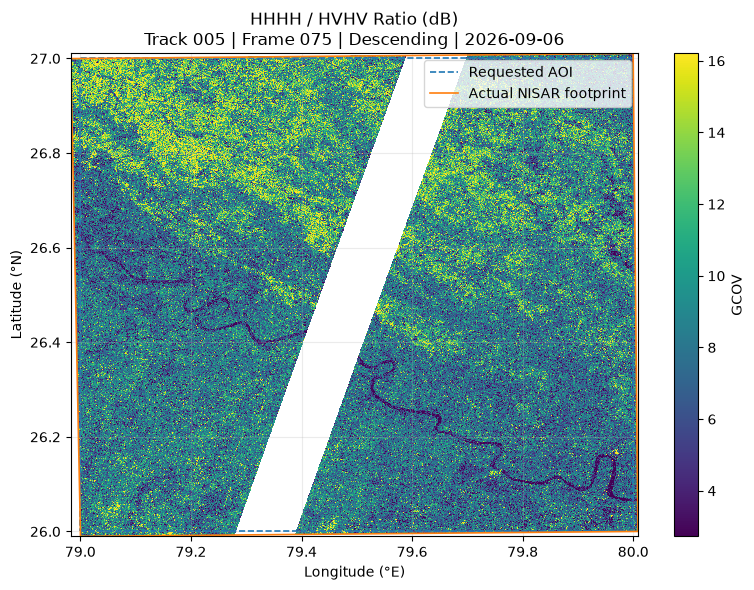

Ratio plot saved: F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906\HHHH_HVHV_Ratio_dB.png


In [5]:
# Select the best available real-valued co-pol/cross-pol pair for RGB.
#
# Generic RGB recipes:
#   LSAR H-pol dual-pol/quad-pol:  R=HHHH, G=HVHV, B=HHHH/HVHV
#   LSAR V-pol-only dual-pol:      R=VVVV, G=VHVH, B=VVVV/VHVH
#   SSAR compact-pol:              R=RHRH, G=RVRV, B=RHRH/RVRV
#
# select_rgb_pair() tries all three in that order and is the same function
# Module 08's unit tests check directly -- so this cell can't silently
# drift out of sync with what's actually verified.
#
# The Gamma-0 channels have already had MASK == 0 set to NaN in the
# preceding data-loading cell, so NaN propagates naturally into the ratio.
from nisar_utils.visualization import select_rgb_pair, RGB_PAIR_CANDIDATES

available_terms = set(term_arrays)
RGB_PAIR = select_rgb_pair(available_terms)

if RGB_PAIR is None:
    print("RGB composite skipped.")
    print("Available real-valued terms:", sorted(available_terms))
    print("Supported RGB pairs:")
    for co_term, cross_term in RGB_PAIR_CANDIDATES:
        print(f"  R={co_term}, G={cross_term}, B={co_term}/{cross_term}")

else:
    CO_TERM, CROSS_TERM = RGB_PAIR
    eps = 1e-10

    CO = np.asarray(term_arrays[CO_TERM], dtype=np.float64)
    CROSS = np.asarray(term_arrays[CROSS_TERM], dtype=np.float64)

    # MASK=0 pixels are already NaN in both source channels, so NaN
    # propagates through the ratio automatically. The +eps before log10
    # (in addition to the +eps in the denominator) guards against a
    # valid, unmasked pixel that happens to have exactly zero co-pol
    # power -- rare with real backscatter data, but log10(0) is -inf,
    # and this keeps that from happening.
    ratio = CO / (CROSS + eps)
    ratio_db = 10.0 * np.log10(ratio + eps)

    print("Selected RGB pair:")
    print("  Co-pol   :", CO_TERM)
    print("  Cross-pol:", CROSS_TERM)
    print("  RGB mapping:")
    print("    R =", CO_TERM)
    print("    G =", CROSS_TERM)
    print("    B =", f"{CO_TERM}/{CROSS_TERM}")
    print("Co-pol shape:", CO.shape)
    print("Cross-pol shape:", CROSS.shape)
    print("Ratio shape:", ratio_db.shape)
    print("Masked ratio NaN pixels:", int(np.count_nonzero(~np.isfinite(ratio_db))))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_gcov_gcs(ratio_db, f"{CO_TERM} / {CROSS_TERM} Ratio (dB)", ax=ax)
    fig.tight_layout()

    ratio_path = OUTPUT_DIR / f"{CO_TERM}_{CROSS_TERM}_Ratio_dB.png"
    fig.savefig(ratio_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Ratio plot saved:", ratio_path)

## RGB Composite

Each channel is normalized independently against its own 2nd and 98th percentiles. The polarization pair is picked automatically -- HHHH/HVHV first, then VVVV/VHVH, then RHRH/RVRV for SSAR compact-pol -- from whichever real-valued channels are actually available, using the same `select_rgb_pair()` the fallback logic is tested against.

- R = co-pol (dB)
- G = cross-pol (dB)
- B = co-pol/cross-pol ratio (dB)

Pixels where `MASK == 0` are NaN in the source channels before this step, so they don't contribute to any of the three channels -- masked-out ground never shows up as valid-looking color in the composite.

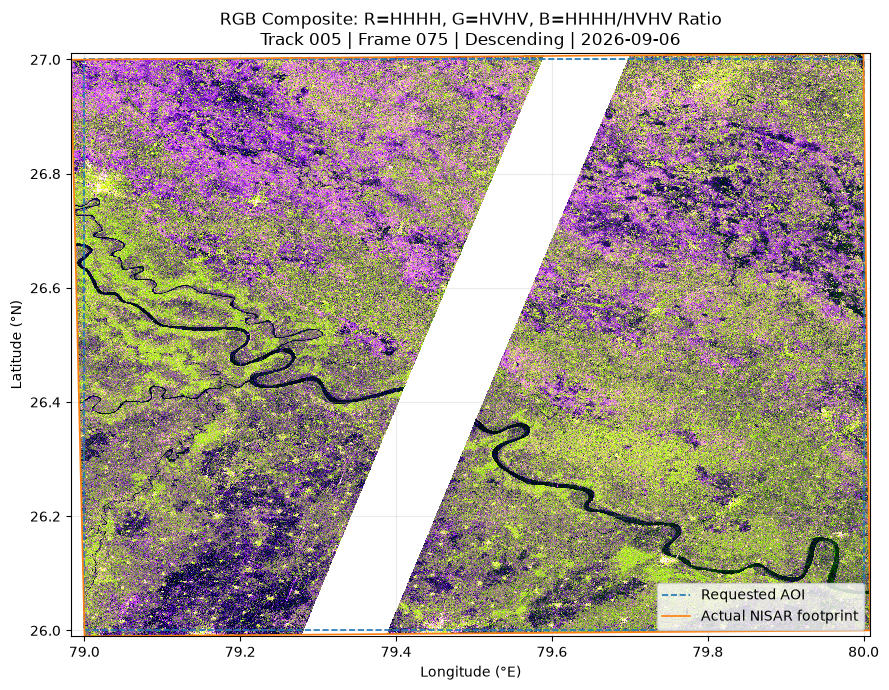

RGB composite saved: F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906\RGB_HHHH_HVHV_Ratio.png
RGB shape: (2106, 1899, 3)
R = HHHH (dB)
G = HVHV (dB)
B = HHHH/HVHV ratio (dB)
RGB polarization pair: HHHH/HVHV
RGB visualization mode: AOI-wide resampled for visualization
MASK=0 pixels excluded from RGB: 430700


In [6]:
if RGB_PAIR is not None:

    CO_TERM, CROSS_TERM = RGB_PAIR
    eps = 1e-10

    CO = np.asarray(term_arrays[CO_TERM], dtype=np.float64)
    CROSS = np.asarray(term_arrays[CROSS_TERM], dtype=np.float64)

    CO_db = 10.0 * np.log10(CO + eps)
    CROSS_db = 10.0 * np.log10(CROSS + eps)

    # MASK=0 pixels are already NaN in CO/CROSS and remain invalid through
    # the ratio and RGB calculations. The +eps before log10 is the same
    # numerical safeguard as the individual ratio cell above.
    ratio = CO / (CROSS + eps)
    ratio_db = 10.0 * np.log10(ratio + eps)

    def normalize_rgb(a, low=2, high=98):
        z = np.asarray(a, dtype=np.float64)
        finite = z[np.isfinite(z)]

        if finite.size == 0:
            return np.zeros(z.shape, dtype=np.float32)

        lo, hi = np.percentile(finite, [low, high])

        if hi <= lo:
            return np.zeros(z.shape, dtype=np.float32)

        out = (z - lo) / (hi - lo)
        return np.clip(out, 0.0, 1.0).astype(np.float32)

    R = normalize_rgb(CO_db)
    G = normalize_rgb(CROSS_db)
    B = normalize_rgb(ratio_db)

    rgb = np.stack([R, G, B], axis=-1)

    # Explicitly preserve invalid pixels as NaN in the RGB array itself,
    # so MASK=0 pixels are never shown as valid-looking RGB information.
    rgb_invalid = (
        ~np.isfinite(CO) |
        ~np.isfinite(CROSS) |
        ~np.isfinite(ratio_db)
    )
    rgb[rgb_invalid, :] = np.nan

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.pcolormesh(LON_plot, LAT_plot, rgb, shading="nearest", rasterized=True)

    ax.set_xlabel("Longitude (\u00b0E)")
    ax.set_ylabel("Latitude (\u00b0N)")
    ax.grid(True, alpha=0.25)

    if user_aoi:
        ax.plot(
            [user_aoi["xmin"], user_aoi["xmax"], user_aoi["xmax"],
             user_aoi["xmin"], user_aoi["xmin"]],
            [user_aoi["ymin"], user_aoi["ymin"], user_aoi["ymax"],
             user_aoi["ymax"], user_aoi["ymin"]],
            linestyle="--", linewidth=1.2, label="Requested AOI"
        )

    ax.plot(
        ACTUAL_FOOTPRINT_LON,
        ACTUAL_FOOTPRINT_LAT,
        linestyle="-",
        linewidth=1.2,
        label="Actual NISAR footprint"
    )
    ax.legend(loc="best")

    ax.set_title(
        f"RGB Composite: R={CO_TERM}, G={CROSS_TERM}, "
        f"B={CO_TERM}/{CROSS_TERM} Ratio"
        f"\n{PASS_ID}"
    )
    fig.tight_layout()

    rgb_path = OUTPUT_DIR / f"RGB_{CO_TERM}_{CROSS_TERM}_Ratio.png"
    fig.savefig(rgb_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("RGB composite saved:", rgb_path)
    print("RGB shape:", rgb.shape)
    print("R =", CO_TERM, "(dB)")
    print("G =", CROSS_TERM, "(dB)")
    print("B =", f"{CO_TERM}/{CROSS_TERM} ratio (dB)")
    print("RGB polarization pair:", f"{CO_TERM}/{CROSS_TERM}")
    print("RGB visualization mode:", plot_mode)
    print("MASK=0 pixels excluded from RGB:", int(np.count_nonzero(rgb_invalid)))
else:
    print("RGB composite not generated because no supported co-pol/cross-pol pair is available.")

In [7]:
print("=" * 70)
print("MODULE 08 COMPLETE")
print("=" * 70)
print("Individual GCOV plots :", OUTPUT_DIR)
print("RGB polarization pair  :", RGB_PAIR if RGB_PAIR else "None")
if RGB_PAIR:
    _co, _cross = RGB_PAIR
    print(f"{_co} plot             :", (OUTPUT_DIR / f"{_co}.png").exists())
    print(f"{_cross} plot             :", (OUTPUT_DIR / f"{_cross}.png").exists())
    print("Ratio plot             :", (OUTPUT_DIR / f"{_co}_{_cross}_Ratio_dB.png").exists())
    print("RGB composite          :", (OUTPUT_DIR / f"RGB_{_co}_{_cross}_Ratio.png").exists())
else:
    print("Ratio/RGB outputs      : SKIPPED — no supported co-pol/cross-pol pair")
print("Complex-value handling : PASS")
print("GCS / WGS84 plotting    : PASS")
print("Full AOI shape          :", (full_rows, full_cols))
print("Visualization shape     :", (plot_rows, plot_cols))
print("Visualization mode      :", plot_mode)
print("Full AOI geographic extent retained: PASS")
print("Requested AOI overlay       : WGS84 user rectangle")
print("Actual NISAR footprint      : transformed selected-grid boundary")
print("Coverage diagnostic         : PASS")
print("RGB generation         :",
      "PASS — best available pair selected" if RGB_PAIR else
      "SKIPPED — no supported pair available")


MODULE 08 COMPLETE
Individual GCOV plots : F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906
RGB polarization pair  : ('HHHH', 'HVHV')
HHHH plot             : True
HVHV plot             : True
Ratio plot             : True
RGB composite          : True
Complex-value handling : PASS
GCS / WGS84 plotting    : PASS
Full AOI shape          : (5597, 5048)
Visualization shape     : (2106, 1899)
Visualization mode      : AOI-wide resampled for visualization
Full AOI geographic extent retained: PASS
Requested AOI overlay       : WGS84 user rectangle
Actual NISAR footprint      : transformed selected-grid boundary
Coverage diagnostic         : PASS
RGB generation         : PASS — best available pair selected


In [8]:
print("=" * 70)
print("MODULE 08 — FINAL END-TO-END STATUS")
print("=" * 70)
print("Acquisition ID:", UNIQUE_OUTPUT_NAME)
print("Output folder :", UNIQUE_OUTPUT_DIR)
print("GCS plotting  : WGS84 / EPSG:4326")
print("AOI overlay   : Requested Module 06 AOI")
print("Plots         : real-valued GCOV channels, selected ratio, RGB")
print("RGB pair      :", RGB_PAIR if RGB_PAIR else "None available")
print("Unique output : PASS")
print("Module 08     : FINAL")


MODULE 08 — FINAL END-TO-END STATUS
Acquisition ID: NISAR_LSAR_005_075_D_20260906
Output folder : F:\Dharmendra\Downloads\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9_FINAL_SCIENTIFIC_QA\NISAR_Polarimetric_Analysis_Training_Package_v9_0_9\outputs\module_08_visualization\NISAR_LSAR_005_075_D_20260906
GCS plotting  : WGS84 / EPSG:4326
AOI overlay   : Requested Module 06 AOI
Plots         : real-valued GCOV channels, selected ratio, RGB
RGB pair      : ('HHHH', 'HVHV')
Unique output : PASS
Module 08     : FINAL


### What this module does, in short

- Works from the Module 06 spatial subset — nothing new is selected here.
- Reads the GCOV `mask` dataset on that same subset and sets `MASK == 0` pixels to NaN in HHHH/HVHV/RHRH/RVRV before anything is plotted, ratioed, or composited.
- Transforms the actual selected pixel coordinates from the product CRS into WGS84 for plotting.
- Shows the requested AOI next to the actual pixel footprint that was read.
- Skips complex channels outright, regardless of polarization mode.
- Labels each plot with its acquisition identity.
- Writes each acquisition to its own folder (`NISAR_<LSAR/SSAR>_<Track>_<Frame>_<A/D>_<YYYYMMDD>`), so a second acquisition won't overwrite the first one's plots.

### A note on AOI-wide visualization

Rather than cropping to a fixed 1024×1024 window, this resolves the full AOI and only downsamples the visualization arrays if the AOI is larger than the plotting budget (4,000,000 pixels, sized for a 16 GB training laptop). The geographic extent shown stays accurate either way — only the plotted resolution shrinks. Full-resolution export is Module 09's job.